<a href="https://colab.research.google.com/github/phoenixxd/colab-notebooks/blob/main/OpenFlamingo_ilovepiano.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Install dependencies


In [1]:
%%bash
# 1) Clean out any old installs
pip uninstall -y torch torchvision torchaudio transformers open-flamingo

# 2) Pin NumPy <2 to keep bitsandbytes, etc. happy
pip install "numpy<2.0"

# 3) Install the exact PyTorch/CUDA stack you want
pip install --extra-index-url https://download.pytorch.org/whl/cu118 \
    torch==2.1.1+cu118 \
    torchvision==0.16.1+cu118 \
    torchaudio==2.1.1+cu118

# 4) Install all the other HF & VLM deps
pip install \
  transformers \
  timm \
  ftfy \
  regex \
  Pillow \
  tqdm \
  bitsandbytes>=0.40.0

# 5) Finally, install OpenFlamingo from GitHub but skip its own dependencies
pip install --no-deps git+https://github.com/mlfoundations/open_flamingo.git@main

Looking in indexes: https://pypi.org/simple, https://download.pytorch.org/whl/cu118
  Using cached https://download.pytorch.org/whl/cu118/torch-2.1.1%2Bcu118-cp311-cp311-linux_x86_64.whl (2326.0 MB)
  Using cached https://download.pytorch.org/whl/cu118/torchvision-0.16.1%2Bcu118-cp311-cp311-linux_x86_64.whl (6.1 MB)
  Using cached https://download.pytorch.org/whl/cu118/torchaudio-2.1.1%2Bcu118-cp311-cp311-linux_x86_64.whl (3.2 MB)
  Using cached https://download.pytorch.org/whl/triton-2.1.0-0-cp311-cp311-manylinux2014_x86_64.manylinux_2_17_x86_64.whl (89.2 MB)
  Attempting uninstall: triton
    Found existing installation: triton 2.0.0
    Uninstalling triton-2.0.0:
      Successfully uninstalled triton-2.0.0
  Cloning https://github.com/mlfoundations/open_flamingo.git (to revision main) to /tmp/pip-req-build-ok9gntxm
  Resolved https://github.com/mlfoundations/open_flamingo.git to commit 655f693fbfa04cd6e9a987d960654624d48917cf
  Preparing metadata (setup.py): started
  Preparing meta

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
sentence-transformers 3.4.1 requires transformers<5.0.0,>=4.41.0, which is not installed.
peft 0.15.2 requires transformers, which is not installed.
  Running command git clone --filter=blob:none --quiet https://github.com/mlfoundations/open_flamingo.git /tmp/pip-req-build-ok9gntxm


In [2]:
import torch, torchvision, torchaudio, transformers, timm
print("torch:", torch.__version__, "| compiler?", hasattr(torch, "compiler"))
print("vision:", torchvision.__version__)
print("audio:", torchaudio.__version__)
print("transformers:", transformers.__version__)
print("timm:", timm.__version__)

torch: 2.1.1+cu118 | compiler? True
vision: 0.16.1+cu118
audio: 2.1.1+cu118
transformers: 4.51.3
timm: 1.0.15


In [3]:
from huggingface_hub import notebook_login
notebook_login()   # ▶️ paste your HF token

In [6]:
from open_flamingo import create_model_and_transforms

model, image_processor, tokenizer = create_model_and_transforms(
    # vision & tokenizer backbones
    clip_vision_encoder_path="ViT-L-14",
    clip_vision_encoder_pretrained="openai",
    lang_encoder_path="anas-awadalla/mpt-1b-redpajama-200b",
    tokenizer_path="anas-awadalla/mpt-1b-redpajama-200b",

    # cross-attn every layer
    cross_attn_every_n_layers=1,

    # leave LM embeddings unfrozen so that, if you train later,
    # only the perceiver and gated_xattn layers get gradients
    freeze_lm_embeddings=False,

    # (optional) use gradient checkpointing inside Flamingo
    gradient_checkpointing=False
)
model = model.to("cuda")
model.eval()


You are using config.init_device='cpu', but you can also use config.init_device="meta" with Composer + FSDP for fast initialization.
Flamingo model initialized with 1046992944 trainable parameters


Flamingo(
  (vision_encoder): VisionTransformer(
    (conv1): Conv2d(3, 1024, kernel_size=(14, 14), stride=(14, 14), bias=False)
    (patch_dropout): Identity()
    (ln_pre): LayerNorm((1024,), eps=1e-05, elementwise_affine=True)
    (transformer): Transformer(
      (resblocks): ModuleList(
        (0-23): 24 x ResidualAttentionBlock(
          (ln_1): LayerNorm((1024,), eps=1e-05, elementwise_affine=True)
          (attn): MultiheadAttention(
            (out_proj): NonDynamicallyQuantizableLinear(in_features=1024, out_features=1024, bias=True)
          )
          (ls_1): Identity()
          (ln_2): LayerNorm((1024,), eps=1e-05, elementwise_affine=True)
          (mlp): Sequential(
            (c_fc): Linear(in_features=1024, out_features=4096, bias=True)
            (gelu): GELU(approximate='none')
            (c_proj): Linear(in_features=4096, out_features=1024, bias=True)
          )
          (ls_2): Identity()
        )
      )
    )
    (ln_post): LayerNorm((1024,), eps=1e-0

Load weights


In [7]:
from huggingface_hub import hf_hub_download
import torch

ckpt = hf_hub_download(
    repo_id="openflamingo/OpenFlamingo-3B-vitl-mpt1b",
    filename="checkpoint.pt",
    revision="main"
)
model.load_state_dict(torch.load(ckpt, map_location="cuda"), strict=False)

checkpoint.pt:   0%|          | 0.00/4.19G [00:00<?, ?B/s]

_IncompatibleKeys(missing_keys=['vision_encoder.class_embedding', 'vision_encoder.positional_embedding', 'vision_encoder.proj', 'vision_encoder.conv1.weight', 'vision_encoder.ln_pre.weight', 'vision_encoder.ln_pre.bias', 'vision_encoder.transformer.resblocks.0.ln_1.weight', 'vision_encoder.transformer.resblocks.0.ln_1.bias', 'vision_encoder.transformer.resblocks.0.attn.in_proj_weight', 'vision_encoder.transformer.resblocks.0.attn.in_proj_bias', 'vision_encoder.transformer.resblocks.0.attn.out_proj.weight', 'vision_encoder.transformer.resblocks.0.attn.out_proj.bias', 'vision_encoder.transformer.resblocks.0.ln_2.weight', 'vision_encoder.transformer.resblocks.0.ln_2.bias', 'vision_encoder.transformer.resblocks.0.mlp.c_fc.weight', 'vision_encoder.transformer.resblocks.0.mlp.c_fc.bias', 'vision_encoder.transformer.resblocks.0.mlp.c_proj.weight', 'vision_encoder.transformer.resblocks.0.mlp.c_proj.bias', 'vision_encoder.transformer.resblocks.1.ln_1.weight', 'vision_encoder.transformer.resbloc

Upload the PDF

Saving Idea 10.pdf to Idea 10.pdf
✔ Uploaded Idea 10.pdf
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 20.0/20.0 MB 44.3 MB/s eta 0:00:00


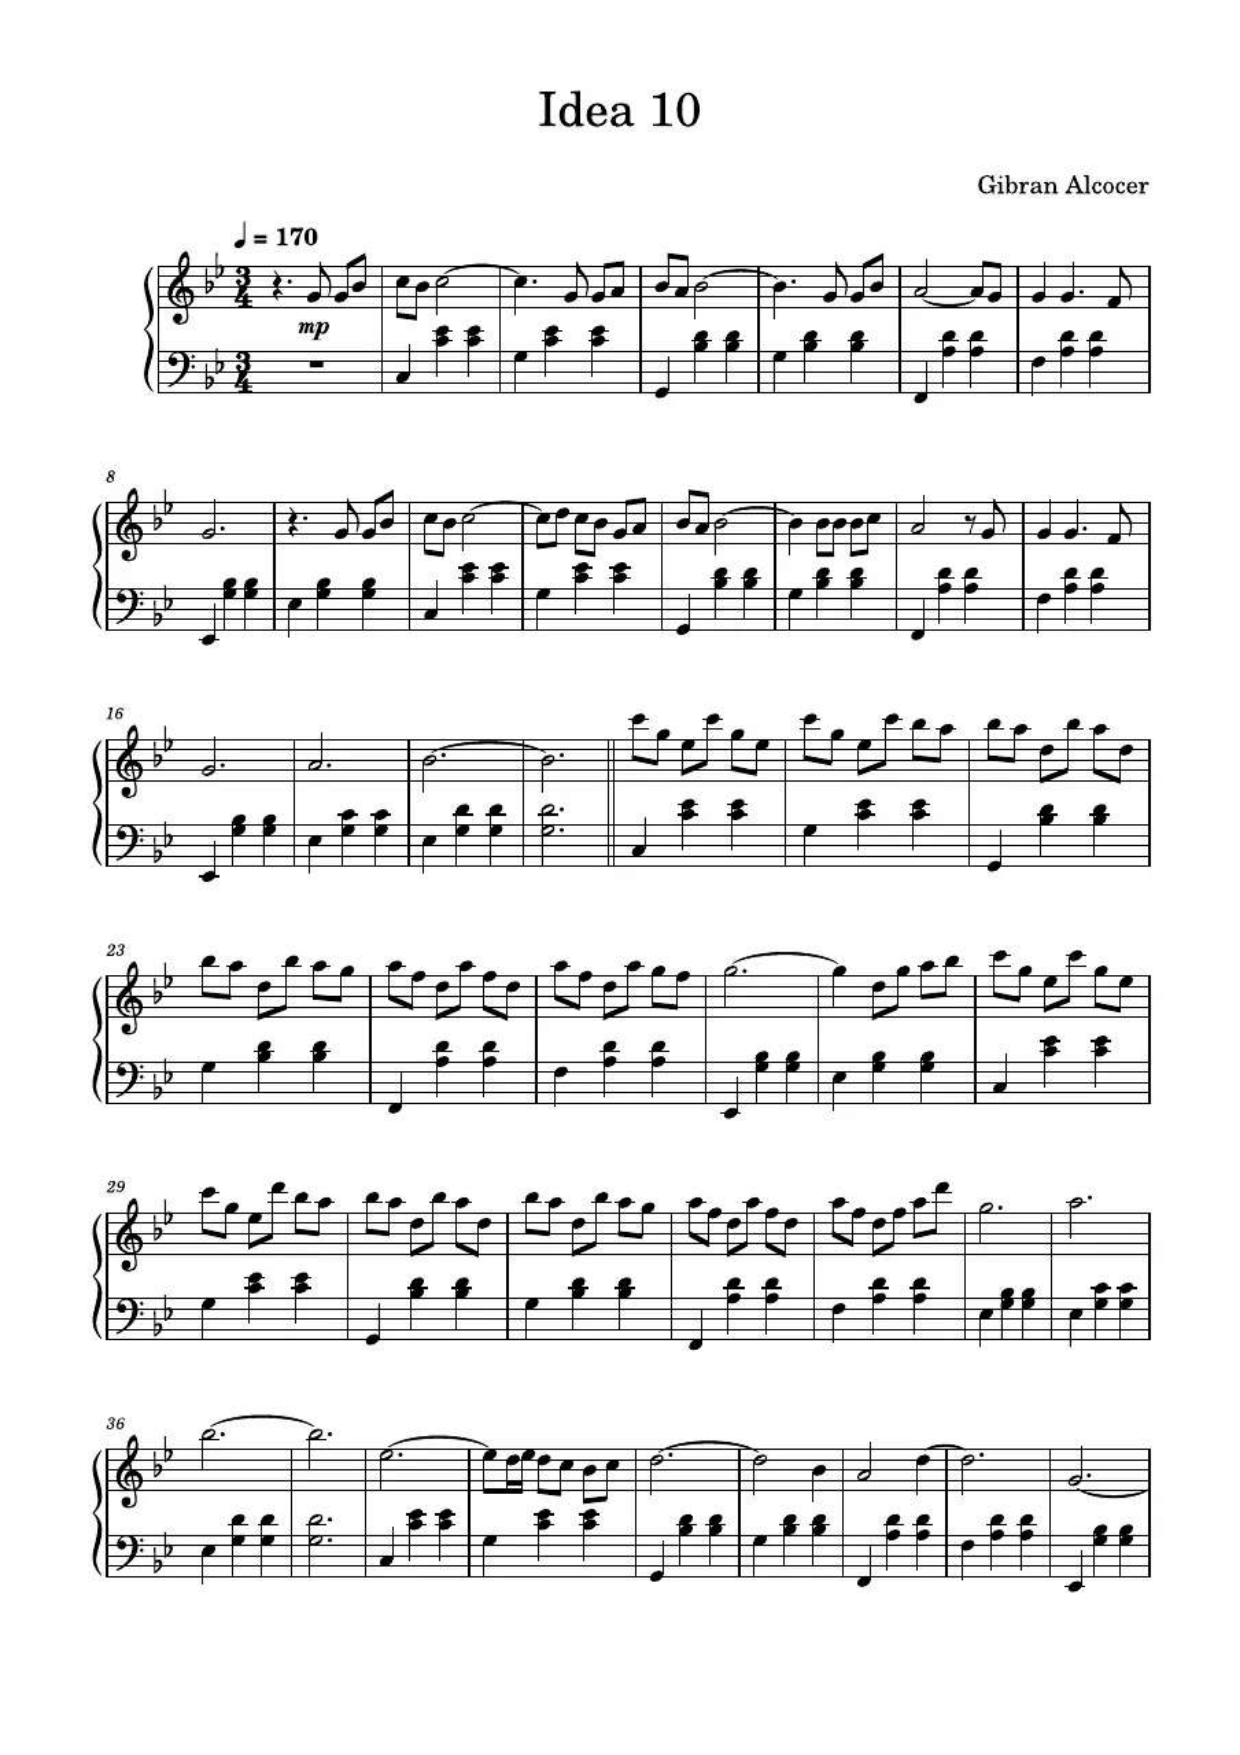

In [8]:
# 1) Prompt the user to upload a PDF
from google.colab import files
uploaded = files.upload()  # pops up a file‐picker

if not uploaded:
    raise RuntimeError("No file uploaded. Please run this cell and choose a PDF.")

# grab the first (and hopefully only) filename
pdf_path = next(iter(uploaded.keys()))
print(f"✔ Uploaded {pdf_path}")

# 2) Install & import PyMuPDF (fitz) to render PDF → image
!pip install PyMuPDF --quiet

import fitz       # PyMuPDF
from PIL import Image
import io

# open the PDF and render page 0
doc = fitz.open(pdf_path)
page = doc.load_page(0)
pix = page.get_pixmap(dpi=150)   # you can bump DPI for higher‐res
img = Image.frombytes("RGB", [pix.width, pix.height], pix.samples)

# (Optional) preview the image in notebook
display(img)

Execute the VLM on the page

In [14]:
# ─── Step 3: Preprocess into vision_x ───────────────────────────
# image_processor(img) returns a (C, H, W) tensor
pixel_values = image_processor(img)          # torch.Tensor of shape [C, H, W]

# add three leading dims: batch, num_images (T_img), frame dim (F)
vision_x = pixel_values.unsqueeze(0)        # [1, C, H, W]
vision_x = vision_x.unsqueeze(0)            # [1, 1, C, H, W]
vision_x = vision_x.unsqueeze(0)            # [1, 1, 1, C, H, W]
vision_x = vision_x.to("cuda")

# ─── Step 4: Tokenize prompt into lang_x ────────────────────────
prompt = "List all the note names (with octave) like C4, E4, etc in the first measure. Preserve the order of the notes in the output, also mention the duration of each note."
lang = tokenizer(
    prompt,
    return_tensors="pt",
    padding=True,
    truncation=True
).to("cuda")
lang_x        = lang.input_ids              # [1, seq_len]
attention_mask = lang.attention_mask        # [1, seq_len]

# ─── Step 5: Generate ───────────────────────────────────────────
generated = model.generate(
  CGXZ
# ─── Step 6: Decode & print ────────────────────────────────────
print(tokenizer.decode(generated[0], skip_special_tokens=True))


Setting `pad_token_id` to `eos_token_id`:50277 for open-end generation.


List all the note names (with octave) like C4, E4, etc in the first measure. Preserve the order of the notes in the output, also mention the duration of each note. The output is a list of all the note names (with octave) in the first measure. The output is a list of all the note names (with octave) in the second measure. The output is a list of all the note names (with octave) in the third measure. The output is a
